In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Load Data
raw_data = load_dataset("lukebarousse/data_jobs")
df = raw_data['train'].to_pandas()

# Cleanup data
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

'\nThe reason swapping the values has no effect is the most important "Aha!" moment in Pandas plotting: When you are plotting a Series, Pandas completely ignores the x and y parameters.\n\nBecause a Series only has one set of labels (the Index) and one set of data (the Values), Pandas assumes you don\'t need to specify which is which. It is "hardwired" to follow a specific blueprint.\n\nThe Series "Hardwired" Blueprint\nWhen you call .plot(kind=\'barh\') on a Series, Pandas follows these rules regardless of what you type inside the parentheses:\n\nVertical Axis (Y): Always the Index (Job Titles).\nHorizontal Axis (X): Always the Values (Salary numbers)\n\nThings are just the reverse in case of Vertical Bar Charts\nX - Index\nY - Values\n'

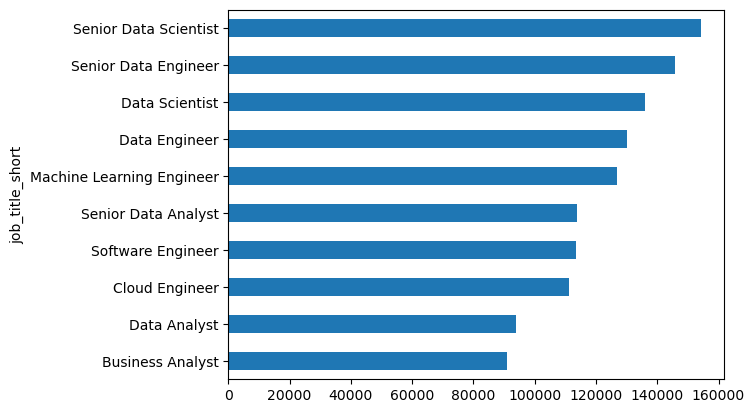

In [6]:
# Graph the average salary (salary_year_avg) by job_title_short as a horizontal bar chart. Order it from the highest salary to the lowest. Include a title, and labels for the x & y-axis.

mean_yearly_avg_salaries = df.groupby('job_title_short')['salary_year_avg'].mean().sort_values() # Series
mean_yearly_avg_salaries.plot(x = mean_yearly_avg_salaries.values, y = mean_yearly_avg_salaries.index, kind = "barh")
# Even swapping Y and X params has no effect on output
"""
The reason swapping the values has no effect is the most important "Aha!" moment in Pandas plotting: When you are plotting a Series, Pandas completely ignores the x and y parameters.

Because a Series only has one set of labels (the Index) and one set of data (the Values), Pandas assumes you don't need to specify which is which. It is "hardwired" to follow a specific blueprint.

The Series "Hardwired" Blueprint
When you call .plot(kind='barh') on a Series, Pandas follows these rules regardless of what you type inside the parentheses:

Vertical Axis (Y): Always the Index (Job Titles).
Horizontal Axis (X): Always the Values (Salary numbers)

Things are just the reverse in case of Vertical Bar Charts
X - Index
Y - Values
"""

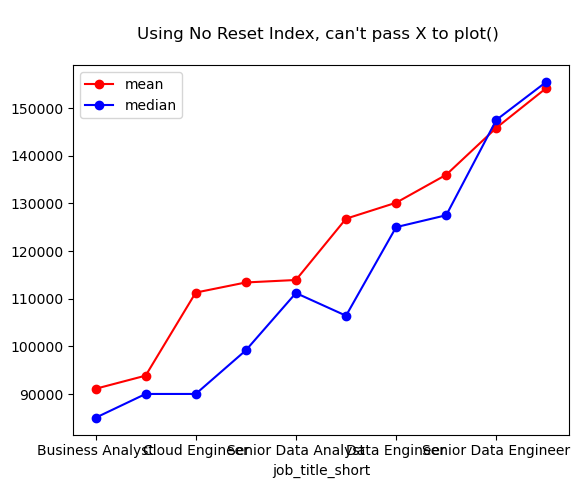

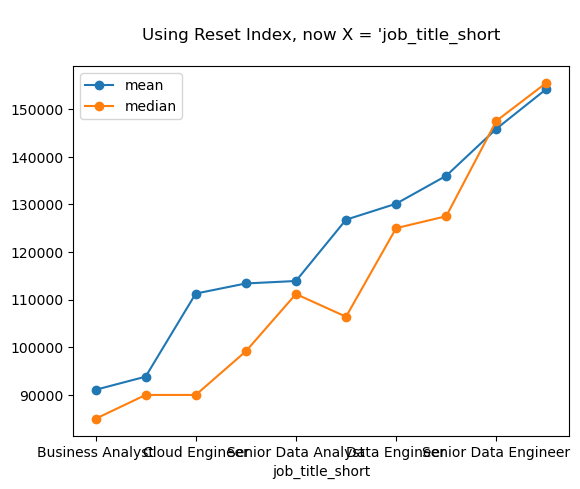

In [ ]:
# Calculate Mean and Median Average yearly salaries w.r.t every job_posted_date, Sorted in Ascending Orderplt.

mean_and_median = df.groupby('job_title_short')['salary_year_avg'].agg(['mean', 'median']).sort_values(by = ['mean', 'median']) # Dataframe
mean_and_median.plot(y = ['mean', 'median'], kind = "line", color = ['red', 'blue'], marker = 'o') # .index will not work as it expects a string, string of column name will also not work as job_title_short is now a special Index column
plt.title("\nUsing No Reset Index, can't pass X to plot() \n")
plt.show()


mean_and_median_reset = mean_and_median.reset_index().sort_values(by = ['mean', 'median']) # Can apply this method to get back the original column name and pass it as string to X
mean_and_median_reset.plot(x = 'job_title_short', y = ['mean', 'median'], marker = 'o')
plt.title("\nUsing Reset Index, now X = 'job_title_short\n")
plt.show()